<div align="center">

![Course](https://img.shields.io/badge/Course-Advanced%20Data%20Science%20Lab-blue?style=for-the-badge&logo=python&logoColor=white)
![Code](https://img.shields.io/badge/Code-MCA33PE21-informational?style=for-the-badge)
![Assignment](https://img.shields.io/badge/Assignment-01-success?style=for-the-badge)

---

# Advanced Data Science Lab [MCA33PE21]
## Practical Assignment - 03
### Installation, Python Programming and Statistical Concepts

---
<br>

| Field | Details |
|---|---|
| **Academic Year** | **2026-2027** |
| **Class / Division** | **SYMCA (Semester-I)** |
| **PRN** | 125M1H026 |
| **Student Name** | Shantanu Suryawanshi |
| **Submission Date** | 26-08-206 |
</div>

# **1) Data Preprocessing and Exploration**

## **a) . You are provided with a dataset containing prices of various electronic products. Some of the entries are outliers due to data entry errors. Your task is to remove these outliers and normalize the remaining prices using Min-Max scaling. (product prices.csv)**

In [ ]:
# Import necessary libraries for data handling and scaling
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Define the path to the product prices dataset
product_prices_path = 'data/product_prices.csv'

# Load the product prices data into a DataFrame
product_prices_df = pd.read_csv(product_prices_path)

# Display the first few rows of the dataset to get a quick look
display(product_prices_df.head())

In [ ]:
# Visualize the 'UnitPrice' column using a box plot to spot outliers
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(y=product_prices_df['UnitPrice'])
plt.title('Box Plot of Product Prices')
plt.ylabel('UnitPrice')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# From the box plot, we can clearly see some prices that are much higher than the rest.

In [ ]:
# Calculate the Interquartile Range (IQR) to identify and remove outliers
Q1 = product_prices_df['UnitPrice'].quantile(0.25)
Q3 = product_prices_df['UnitPrice'].quantile(0.75)
IQR = Q3 - Q1

# Define the bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out the rows where 'UnitPrice' falls outside the bounds
product_prices_filtered_df = product_prices_df[(product_prices_df['UnitPrice'] >= lower_bound) & (product_prices_df['UnitPrice'] <= upper_bound)]

# Report how many outliers were removed
outliers_removed_count = len(product_prices_df) - len(product_prices_filtered_df)
print(f"Number of outliers removed from 'UnitPrice' column: {outliers_removed_count}")

# Display the statistics of the price after removing outliers
print("\n--- Descriptive Statistics for UnitPrice After Outlier Removal ---")
print(product_prices_filtered_df['UnitPrice'].describe())

# Display the first few rows of the DataFrame without outliers
display(product_prices_filtered_df.head())

In [ ]:
# Initialize the Min-Max scaler
scaler = MinMaxScaler()

# Apply Min-Max scaling to the 'UnitPrice' column.
# We reshape it to a 2D array because scaler expects 2D input.
product_prices_filtered_df['Normalized_Price'] = scaler.fit_transform(product_prices_filtered_df[['UnitPrice']])

# Display the DataFrame with the new normalized 'Price' column
print("\n--- DataFrame with Normalized Prices ---")
display(product_prices_filtered_df.head())

## **b) A retail store wants to analyze the age and gender distribution of its customers. You are required to encode the gender column and generate statistical summaries of customer ages. (customers.csv)**

In [ ]:
# Import pandas for data manipulation
import pandas as pd

# Define the path to the customers dataset
customers_path = 'dataata/customers.csv'

# Load the customer data into a DataFrame
customers_df = pd.read_csv(customers_path)

# Display the first few rows to understand its structure
print("--- Original Customer Data ---")
display(customers_df.head())

# Show basic info about the customer DataFrame
print("\n--- Customer Data Info ---")
customers_df.info()

In [ ]:
# Import LabelEncoder for encoding categorical data
from sklearn.preprocessing import LabelEncoder

# Initialize the LabelEncoder
label_encoder = LabelEncoder()

# Encode the 'Gender' column into numerical representation
# This creates a new column for the encoded gender
customers_df['Gender_Encoded'] = label_encoder.fit_transform(customers_df['Gender'])

# Display the unique values of the original and encoded gender columns
print("Original Gender Unique Values:", customers_df['Gender'].unique())
print("Encoded Gender Unique Values:", customers_df['Gender_Encoded'].unique())

# Show the DataFrame with the new encoded gender column
print("\n--- Customer Data with Encoded Gender ---")
display(customers_df.head())

In [ ]:
# Generate statistical summaries for the 'Age' column
# This includes count, mean, standard deviation, min, max, and quartiles
print("--- Statistical Summary of Customer Ages ---")
print(customers_df['Age'].describe())

# Optionally, visualize the age distribution using a histogram
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(customers_df['Age'], bins=10, kde=True)
plt.title('Distribution of Customer Ages')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# **2) Feature Engineering**

## **a) You are working with a customer dataset and want to create new age categories, such as "Youth", "Adult", etc., to be used in targeted marketing. Your task is to define bins and convert the continuous age column into categorical age groups. (ages.csv)**

In [ ]:
# Import pandas for data handling
import pandas as pd

# Define the path to the ages dataset
ages_path = 'dataata/ages.csv'

# Load the ages data into a DataFrame
ages_df = pd.read_csv(ages_path)

# Display the first few rows of the dataset
print("--- Original Ages Data ---")
display(ages_df.head())

# Display basic information about the DataFrame
print("\n--- Ages Data Info ---")
ages_df.info()

In [ ]:
# Define age bins and corresponding labels for categorization
age_bins = [0, 18, 35, 60, 100]
age_labels = ['Youth', 'Adult', 'Senior', 'Elderly']

# Create a new column 'Age_Category' by categorizing the 'Age' column
ages_df['Age_Category'] = pd.cut(ages_df['Age'], bins=age_bins, labels=age_labels, right=False)

# Display the DataFrame with the new age categories
print("--- Ages Data with Categories ---")
display(ages_df.head())

# Show the count of each age category
print("\n--- Age Category Counts ---")
print(ages_df['Age_Category'].value_counts())

## **b) The retail store wants to understand customer purchasing behavior over time. Your task is to engineer the following features: (sales.csv)**

In [ ]:
# Import pandas for data manipulation
import pandas as pd

# Define the path to the sales dataset
sales_path = 'dataata/sales.csv'

# Load the sales data into a DataFrame
sales_df = pd.read_csv(sales_path)

# Display the first few rows of the dataset
print("--- Original Sales Data ---")
display(sales_df.head())

# Display basic information about the DataFrame, especially to check 'Date' column type
print("\n--- Sales Data Info ---")
sales_df.info()

 i. Extract the day of the week and month from the Date column.

In [ ]:
# Convert the 'Date' column to datetime objects to enable date-time operations
sales_df['Date'] = pd.to_datetime(sales_df['Date'])

# i. Extract the day of the week and month from the 'Date' column
# 'day_name()' returns the full name of the day
sales_df['DayOfWeek'] = sales_df['Date'].dt.day_name()
# 'month_name()' returns the full name of the month
sales_df['Month'] = sales_df['Date'].dt.month_name()

# Display the DataFrame with the newly extracted features
print("--- Sales Data with Day of Week and Month ---")
display(sales_df.head())

 ii. Create a high-value transaction flag: if TotalPurchase is greater than ₹10,000, mark it asyl (high-value), else 0

In [ ]:
# ii. Create a high-value transaction flag

# First, calculate 'TotalPurchase' as Quantity * UnitPrice
sales_df['TotalPurchase'] = sales_df['Quantity'] * sales_df['UnitPrice']

# Define the threshold for a high-value transaction
high_value_threshold = 10000

# Create 'HighValue_Transaction' column: 1 if TotalPurchase > threshold, else 0
sales_df['HighValue_Transaction'] = (sales_df['TotalPurchase'] > high_value_threshold).astype(int)

# Display the DataFrame with the new high-value transaction flag
print("--- Sales Data with High-Value Transaction Flag ---")
display(sales_df.head())

# Show the count of high-value vs. regular transactions
print("\n--- High-Value Transaction Counts ---")
print(sales_df['HighValue_Transaction'].value_counts())

In [ ]:
# iii. Create a feature called 'Category' based on the 'Item' name using manual mapping
# Define a mapping dictionary for items to categories
item_to_category_mapping = {
    'Mouse': 'Accessories',
    'Keyboard': 'Accessories',
    'Laptop': 'Electronics',
    'Tablet': 'Electronics',
    'Headphones': 'Audio',
    'Monitor': 'Electronics',
    'Speaker': 'Audio',
    'Printer': 'Office Equipment',
    'Webcam': 'Accessories',
    'Smartphone': 'Electronics'
}

# Apply the mapping to create the 'Category' column
# Use .map() and fill any unmapped items with 'Other' or a more appropriate default
sales_df['Category'] = sales_df['Item'].map(item_to_category_mapping).fillna('Other')

# Display the DataFrame with the new 'Category' column
print("--- Sales Data with Item Category ---")
display(sales_df.head())

# Show the count of items per category
print("\n--- Item Category Counts ---")
print(sales_df['Category'].value_counts())

# **3) Handling Missing Data**

## **a) A retail chain maintains a customer dataset including age, income, and loyalty score. Some of the values are missing due to entry gaps. (missing_customers.csv)**

In [ ]:
# Import pandas for data manipulation
import pandas as pd

# Define the path to the missing customers dataset
missing_customers_path = 'dataata/missing_customers.csv'

# Load the missing customers data into a DataFrame
missing_customers_df = pd.read_csv(missing_customers_path)

# Display the first few rows of the dataset to see the raw data, including missing values
print("--- Original Missing Customers Data ---")
display(missing_customers_df.head())

# Display basic information to get an overview of data types and non-null counts
print("\n--- Missing Customers Data Info ---")
missing_customers_df.info()

#### i. Identify columns with missing data.

In [ ]:
# Identify columns with any missing data and count the number of missing values per column
print("--- Missing Values Count Per Column ---")
missing_values = missing_customers_df.isnull().sum()
# Filter to show only columns with missing values
missing_values_cols = missing_values[missing_values > 0]
print(missing_values_cols)

#### ii. Fill missing values in Age with the mean, and in AnnualIncome with the median.

In [ ]:
# Fill missing 'Age' values with the mean of the 'Age' column
mean_age = missing_customers_df['Age'].mean()
missing_customers_df['Age'].fillna(mean_age, inplace=True)
print(f"Missing 'Age' values filled with mean: {mean_age:.2f}")

# Fill missing 'AnnualIncome' values with the median of the 'AnnualIncome' column
median_annual_income = missing_customers_df['AnnualIncome'].median()
missing_customers_df['AnnualIncome'].fillna(median_annual_income, inplace=True)
print(f"Missing 'AnnualIncome' values filled with median: {median_annual_income}")

# Display info again to confirm 'Age' and 'AnnualIncome' missing values are handled
print("\n--- Missing Customers Data Info After Age and Income Imputation ---")
missing_customers_df.info()

#### iii. If Gender has missing values, fill them using the mode.

In [ ]:
# Fill missing 'Gender' values with the mode of the 'Gender' column
# The mode() method can return multiple values if there's a tie, so we take the first one.
mode_gender = missing_customers_df['Gender'].mode()[0]
missing_customers_df['Gender'].fillna(mode_gender, inplace=True)
print(f"Missing 'Gender' values filled with mode: {mode_gender}")

# Display info again to confirm 'Gender' missing values are handled
print("\n--- Missing Customers Data Info After Gender Imputation ---")
missing_customers_df.info()

#### iv. Ensure the cleaned dataset is ready for further analysis.

In [ ]:
# Verify that there are no more missing values in the entire DataFrame
print("--- Final Check for Missing Values ---")
print(missing_customers_df.isnull().sum())

# Display the head of the cleaned DataFrame
print("\n--- Cleaned Customers Dataset (First 5 Rows) ---")
display(missing_customers_df.head())

# Display descriptive statistics for the cleaned numerical columns for final review
print("\n--- Descriptive Statistics for Cleaned Numerical Columns ---")
print(missing_customers_df[['Age', 'AnnualIncome', 'LoyaltyScore']].describe())

## **b) A university wants to analyze exam results for internal assessment. But the dataset contains several rows with incomplete information, like missing Score, Subject, or Grade. (exam results.csv)**

In [ ]:
# Import pandas for data manipulation
import pandas as pd

# Define the path to the exam results dataset
exam_results_path = 'dataata/exam_results.csv'

# Load the exam results data into a DataFrame
exam_results_df = pd.read_csv(exam_results_path)

# Display the first few rows of the dataset to see the raw data, including missing values
print("--- Original Exam Results Data ---")
display(exam_results_df.head())

# Display basic information to get an overview of data types and non-null counts
print("\n--- Exam Results Data Info ---")
exam_results_df.info()

#### i. Detect all rows with any missing value.

In [ ]:
# Identify rows that contain any missing values
# .isnull() creates a boolean DataFrame indicating missing values
# .any(axis=1) checks if any column in a row has a missing value
missing_rows = exam_results_df[exam_results_df.isnull().any(axis=1)]

print("--- Rows with Missing Values ---")
display(missing_rows)
print(f"Total rows with missing values: {len(missing_rows)}")

#### ii. Drop these rows entirely to maintain the integrity of statistical analysis.

In [ ]:
# Drop rows that contain any missing values
# how='any' means drop a row if any NaN is present
exam_results_cleaned_df = exam_results_df.dropna(how='any')

# Report how many rows were dropped
rows_dropped = len(exam_results_df) - len(exam_results_cleaned_df)
print(f"Number of rows dropped due to missing values: {rows_dropped}")

# Display info of the cleaned DataFrame to confirm removal of missing values
print("\n--- Cleaned Exam Results Data Info ---")
exam_results_cleaned_df.info()

#### iii. Output a clean dataset ready for descriptive statistics.

In [ ]:
# Display the first few rows of the cleaned dataset
print("--- Cleaned Exam Results Dataset (First 5 Rows) ---")
display(exam_results_cleaned_df.head())

# Verify that there are no more missing values in the cleaned DataFrame
print("\n--- Final Check for Missing Values in Cleaned Data ---")
print(exam_results_cleaned_df.isnull().sum())

# Display descriptive statistics for numerical columns in the cleaned dataset
print("\n--- Descriptive Statistics for Cleaned Exam Results ---")
print(exam_results_cleaned_df.describe())

# **4) Exploratory Data Analysis (EDA): Univariate and Bivariate Analysis**

##  **a) A retail company has provided a customer dataset containing demographic and spending information such as age, gender, annual income, and spending score. Your task is to perform exploratory data analysis with the following goals. (customer data.csv)**

In [ ]:
# Import pandas for data manipulation
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the path to the customer data dataset
customer_data_path = 'dataata/customer_data.csv'

# Load the customer data into a DataFrame
customer_df = pd.read_csv(customer_data_path)

# Display the first few rows of the dataset
print("--- Original Customer Data ---")
display(customer_df.head())

# Display basic information about the DataFrame
print("\n--- Customer Data Info ---")
customer_df.info()

# Print column names to identify the correct ones for 'Spending Score' and 'Annual Income'
print("\n--- Customer Data Columns ---")
print(customer_df.columns)

## **Univariate Analysis**

#### i. Plot the distribution of customer ages using a histogram.

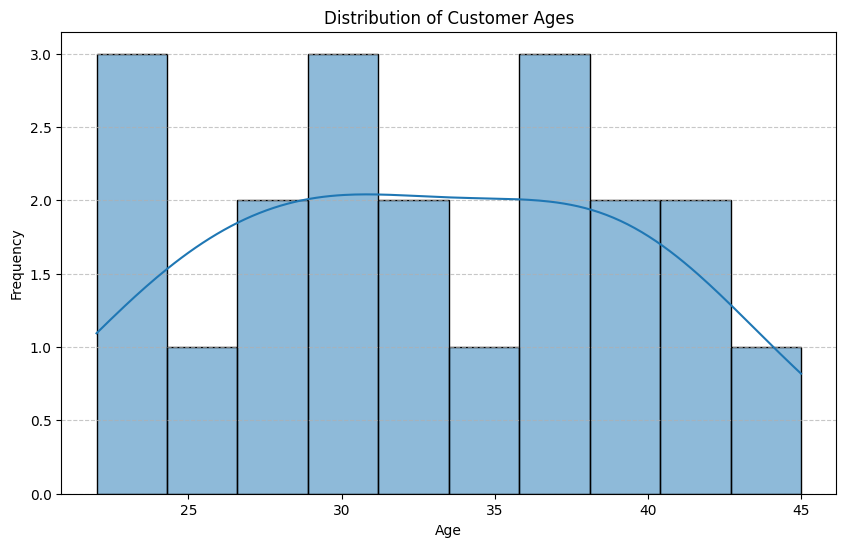

In [34]:
# i. Plot the distribution of customer ages using a histogram
plt.figure(figsize=(10, 6))
sns.histplot(customer_df['Age'], bins=10, kde=True)
plt.title('Distribution of Customer Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### ii. Analyze gender distribution using a count plot.

/tmp/ipykernel_542/2176759489.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=customer_df, palette='viridis')


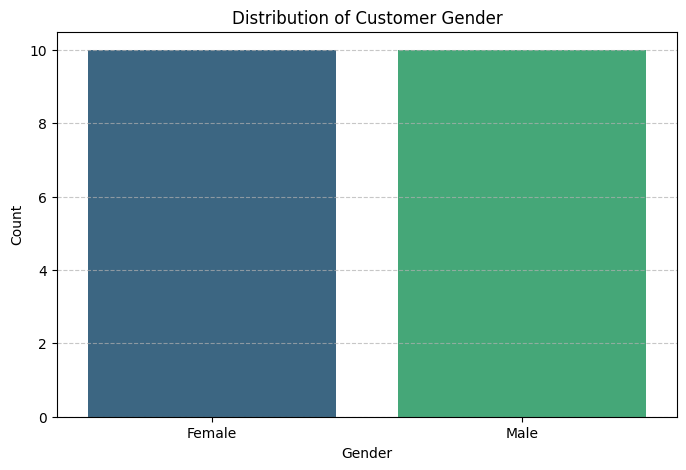

In [35]:
# ii. Analyze gender distribution using a count plot
plt.figure(figsize=(8, 5))
sns.countplot(x='Gender', data=customer_df, palette='viridis')
plt.title('Distribution of Customer Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### iii. Visualize spending scores using a box plot.

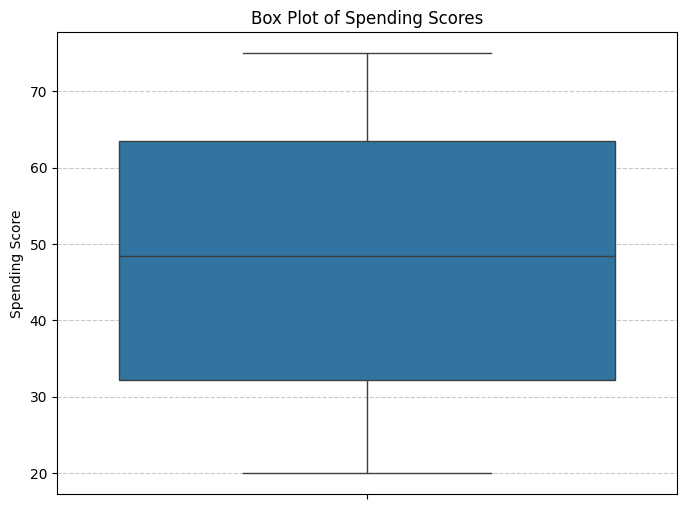

In [47]:
# iii. Visualize spending scores using a box plot
plt.figure(figsize=(8, 6))
sns.boxplot(y=customer_df['SpendingScore'])
plt.title('Box Plot of Spending Scores')
plt.ylabel('Spending Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## **Bivariate Analysis**

#### iv. Explore the relationship between age and spending score using a scatter plot.

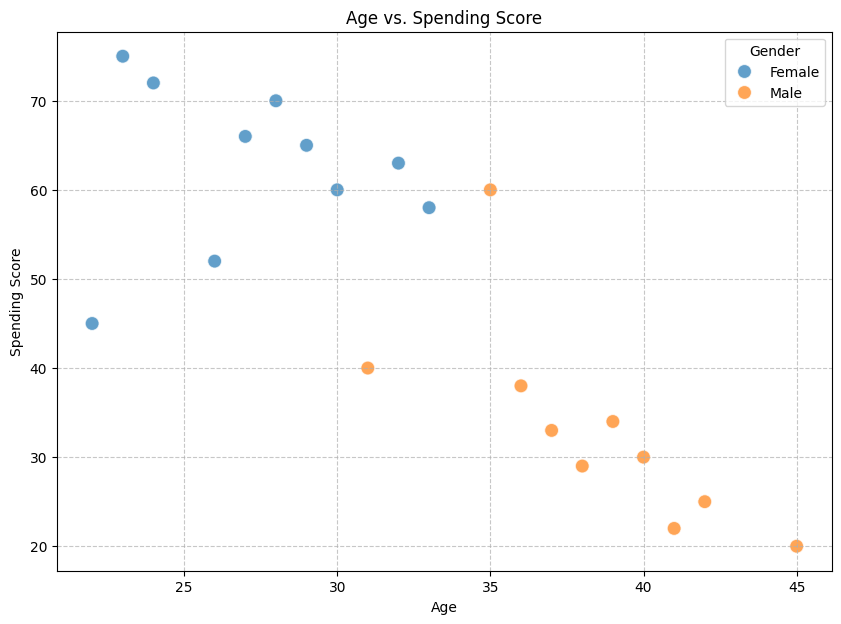

In [48]:
# iv. Explore the relationship between age and spending score using a scatter plot
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Age', y='SpendingScore', data=customer_df, hue='Gender', s=100, alpha=0.7)
plt.title('Age vs. Spending Score')
plt.xlabel('Age')
plt.ylabel('Spending Score')
plt.grid(linestyle='--', alpha=0.7)
plt.show()

#### v. Analyze spending behavior across genders using bar plots.

/tmp/ipykernel_542/4189079132.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gender', y='SpendingScore', data=customer_df, palette='muted')


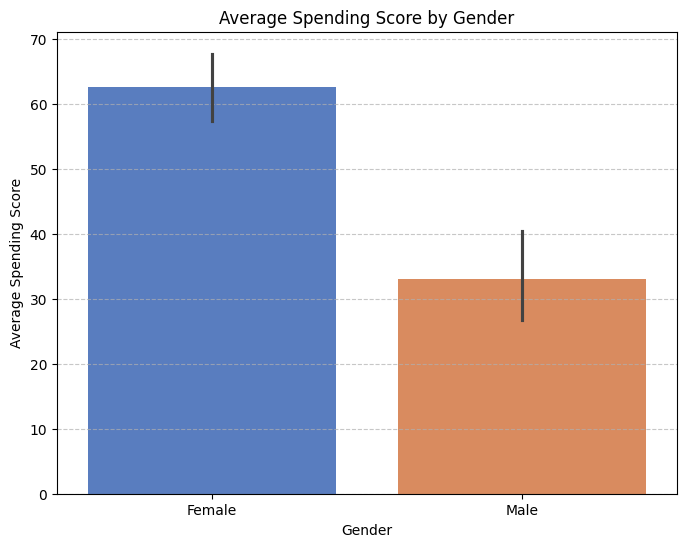

In [49]:
# v. Analyze spending behavior across genders using bar plots
plt.figure(figsize=(8, 6))
sns.barplot(x='Gender', y='SpendingScore', data=customer_df, palette='muted')
plt.title('Average Spending Score by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Spending Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### vi. Compare annual income with spending score using a scatter or regression plot.

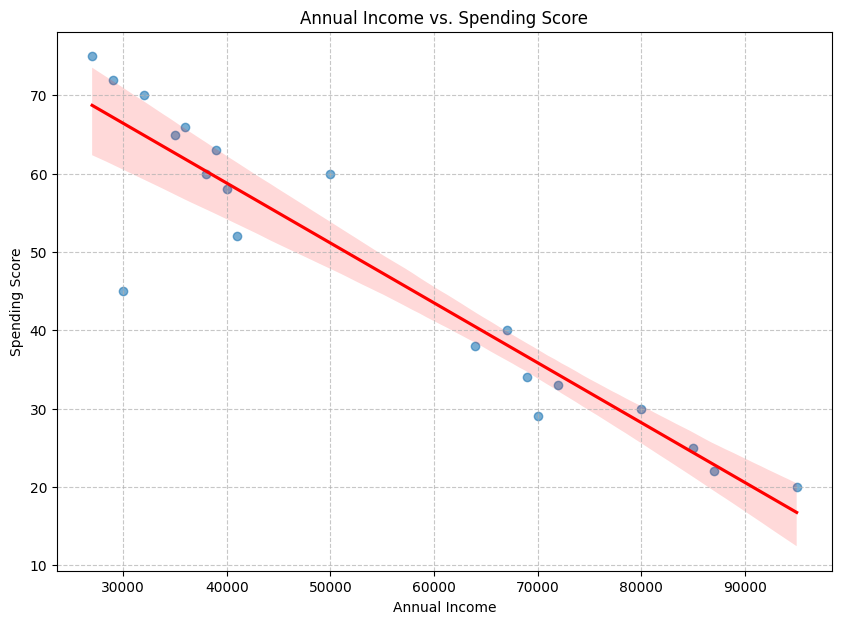

In [50]:
# vi. Compare annual income with spending score using a scatter or regression plot
plt.figure(figsize=(10, 7))
sns.regplot(x='AnnualIncome', y='SpendingScore', data=customer_df, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Annual Income vs. Spending Score')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.grid(linestyle='--', alpha=0.7)
plt.show()

##  **b) You are provided with a retail sales dataset containing product categories, unit prices, quantities sold, total sales, and regional information. Your task is to perform exploratory data analysis with the following objectives. (product sales.csv)**

In [ ]:
# Import pandas for data manipulation
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the path to the product sales dataset
product_sales_path = 'dataata/product_sales.csv'

# Load the product sales data into a DataFrame
product_sales_df = pd.read_csv(product_sales_path)

# Display the first few rows of the dataset
print("--- Original Product Sales Data ---")
display(product_sales_df.head())

# Display basic information about the DataFrame
print("\n--- Product Sales Data Info ---")
product_sales_df.info()

--- Original Product Sales Data ---


,ProductID,Category,Region,UnitPrice,QuantitySold,TotalSales,Discount
0,101,Electronics,North,1200,15,18000,0.10
1,102,Fashion,South,1500,8,12000,0.15
2,103,Electronics,West,1100,20,22000,0.05
3,104,Home,East,900,18,16200,0.10
4,105,Fashion,North,1300,12,15600,0.20



--- Product Sales Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ProductID     20 non-null     int64  
 1   Category      20 non-null     object 
 2   Region        20 non-null     object 
 3   UnitPrice     20 non-null     int64  
 4   QuantitySold  20 non-null     int64  
 5   TotalSales    20 non-null     int64  
 6   Discount      20 non-null     float64
dtypes: float64(1), int64(4), object(2)
memory usage: 1.2+ KB


## **Univariate Analysis**

#### i. Analyze the distribution of unit prices using a histogram.

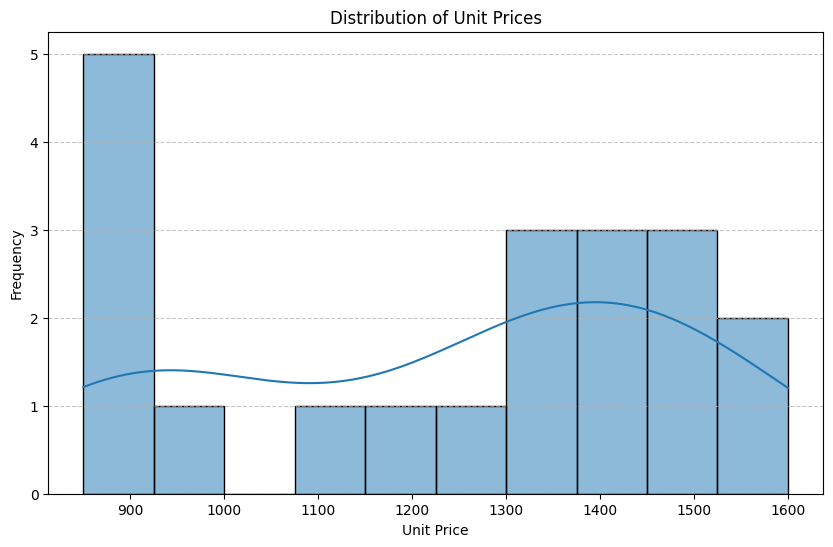

In [41]:
# i. Analyze the distribution of unit prices using a histogram
plt.figure(figsize=(10, 6))
sns.histplot(product_sales_df['UnitPrice'], bins=10, kde=True)
plt.title('Distribution of Unit Prices')
plt.xlabel('Unit Price')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### ii. Examine the spread and outliers in total sales using a box plot.

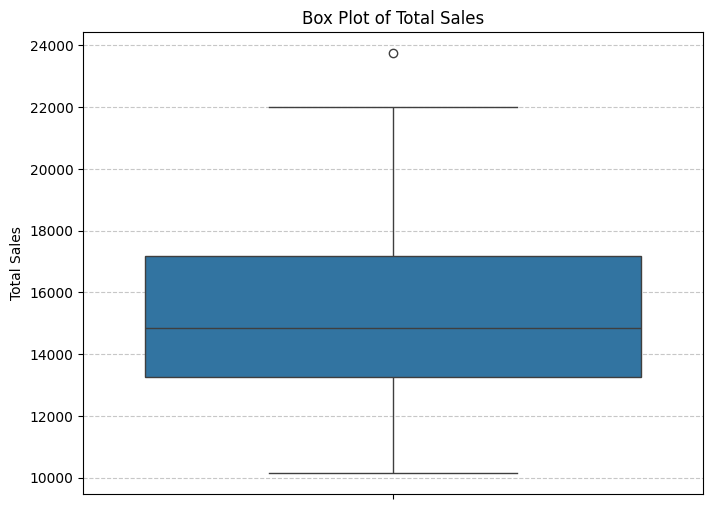

In [42]:
# ii. Examine the spread and outliers in total sales using a box plot
plt.figure(figsize=(8, 6))
sns.boxplot(y=product_sales_df['TotalSales'])
plt.title('Box Plot of Total Sales')
plt.ylabel('Total Sales')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## **Bivariate Analysis**

#### iii. Identify the top-selling product categories using total sales grouped by category.

/tmp/ipykernel_542/1293830272.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index, y=category_sales.values, palette='coolwarm')


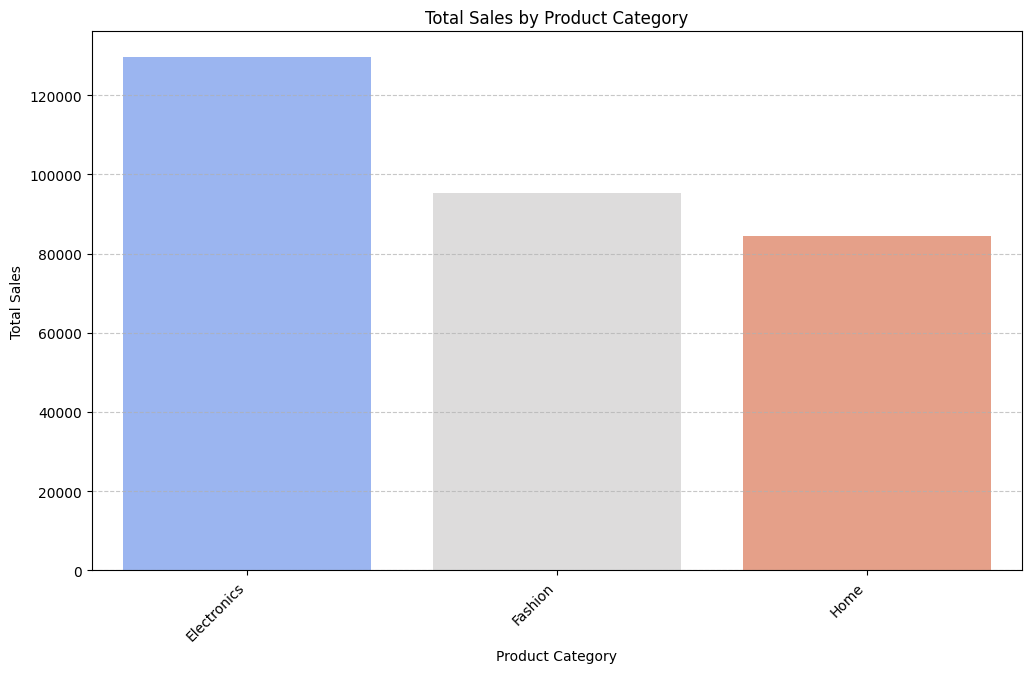

In [43]:
# iii. Identify the top-selling product categories using total sales grouped by category
category_sales = product_sales_df.groupby('Category')['TotalSales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=category_sales.index, y=category_sales.values, palette='coolwarm')
plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### iv. Compare regional sales performance using a bar plot.

/tmp/ipykernel_542/3017013559.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=regional_sales.index, y=regional_sales.values, palette='mako')


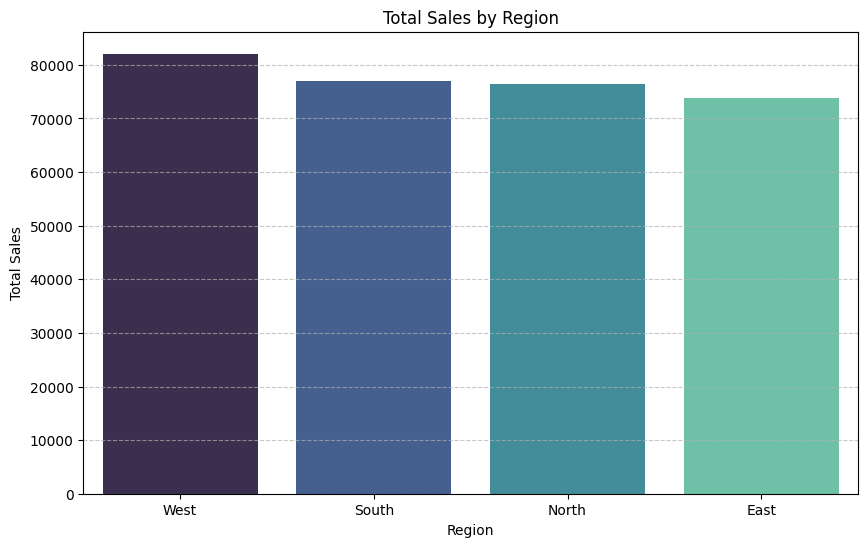

In [44]:
# iv. Compare regional sales performance using a bar plot
regional_sales = product_sales_df.groupby('Region')['TotalSales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=regional_sales.index, y=regional_sales.values, palette='mako')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### v. Use a count plot to visualize the number of products sold across regions and categories.

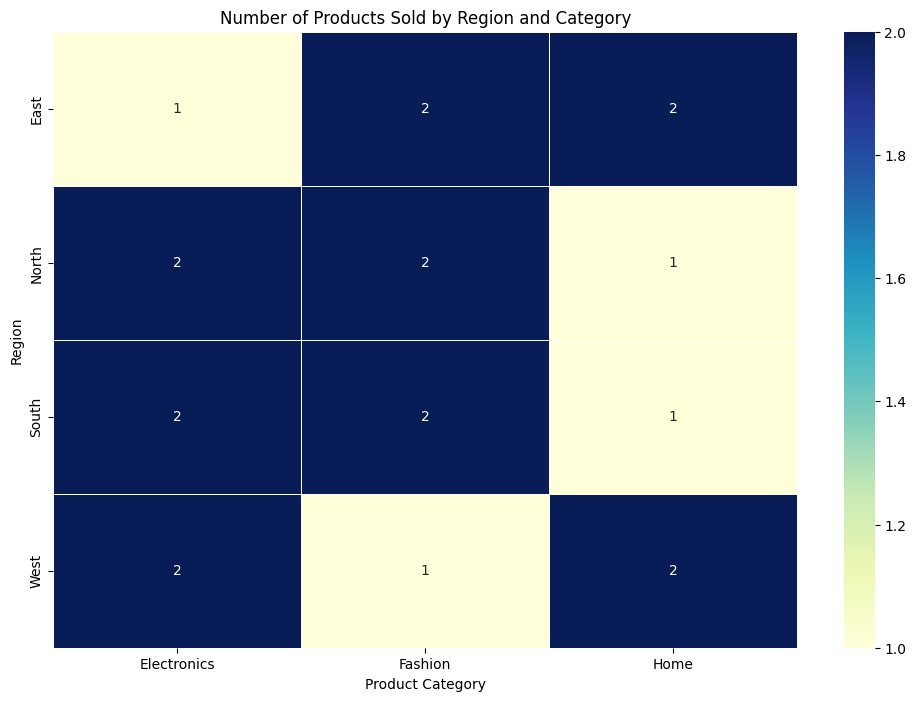

/tmp/ipykernel_542/1229875121.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Region', data=product_sales_df, palette='Spectral')
/tmp/ipykernel_542/1229875121.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Category', data=product_sales_df, palette='Spectral')


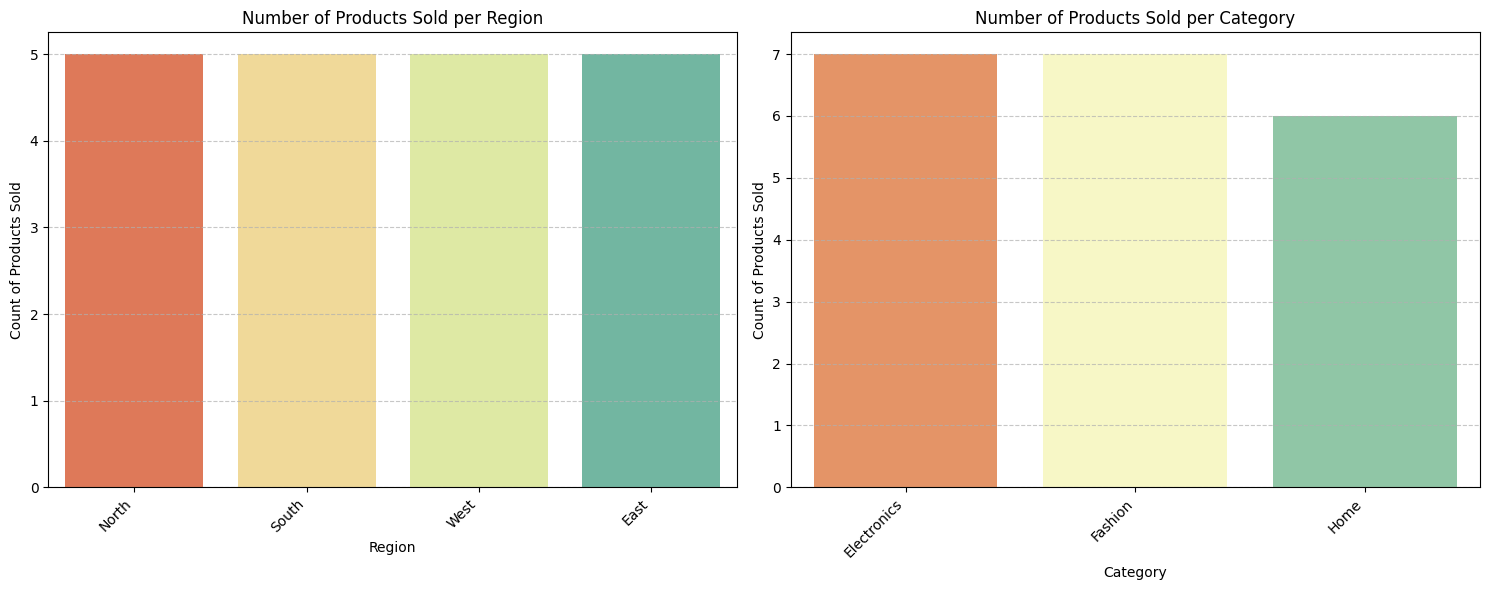

In [45]:
# v. Use a count plot to visualize the number of products sold across regions and categories.
# This can be interpreted in a few ways. Let's visualize the count of sales records
# for each Region and Category combination using a heatmap for better overview.

# First, create a cross-tabulation of counts for Region and Category
region_category_counts = pd.crosstab(product_sales_df['Region'], product_sales_df['Category'])

plt.figure(figsize=(12, 8))
sns.heatmap(region_category_counts, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5)
plt.title('Number of Products Sold by Region and Category')
plt.xlabel('Product Category')
plt.ylabel('Region')
plt.show()

# Alternatively, individual count plots for products per region and products per category
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1) # First subplot for Region
sns.countplot(x='Region', data=product_sales_df, palette='Spectral')
plt.title('Number of Products Sold per Region')
plt.xlabel('Region')
plt.ylabel('Count of Products Sold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2) # Second subplot for Category
sns.countplot(x='Category', data=product_sales_df, palette='Spectral')
plt.title('Number of Products Sold per Category')
plt.xlabel('Category')
plt.ylabel('Count of Products Sold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# **5) Exploratory Data Analysis (EDA): Multivariate Analysis**

## **a) An educational institution wants to understand how students' performance in Math, Reading, and Writing is influenced by gender, parental education level, and lunch type. Your task is to conduct multivariate analysis to uncover key relationships and visualize how multiple variables interact to influence academic scores. (student_scores.csv)**

In [ ]:
# Import pandas for data manipulation and seaborn/matplotlib for plotting
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the path to the student scores dataset
student_scores_path = 'dataata/student_scores.csv'

# Load the student scores data into a DataFrame
student_df = pd.read_csv(student_scores_path)

# Display the first few rows of the dataset
print("-- Original Student Scores Data --")
display(student_df.head())

# Display basic information about the DataFrame
print("\n-- Student Scores Data Info --")
student_df.info()


-- Original Student Scores Data --


,StudentID,Gender,ParentalEducation,Lunch,MathScore,ReadingScore,WritingScore
0,1,Female,Bachelor,Standard,78,85,82
1,2,Male,HighSchool,Free,65,70,68
2,3,Female,Master,Standard,90,95,92
3,4,Male,Associate,Standard,72,75,70
4,5,Female,SomeCollege,Free,60,65,63



-- Student Scores Data Info --
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   StudentID          20 non-null     int64 
 1   Gender             20 non-null     object
 2   ParentalEducation  20 non-null     object
 3   Lunch              20 non-null     object
 4   MathScore          20 non-null     int64 
 5   ReadingScore       20 non-null     int64 
 6   WritingScore       20 non-null     int64 
dtypes: int64(4), object(3)
memory usage: 1.2+ KB


## **Multivariate Analysis**

#### i. Analyze average performance across gender using a grouped bar chart to compare mean Math, Reading, and Writing scores for males and females.

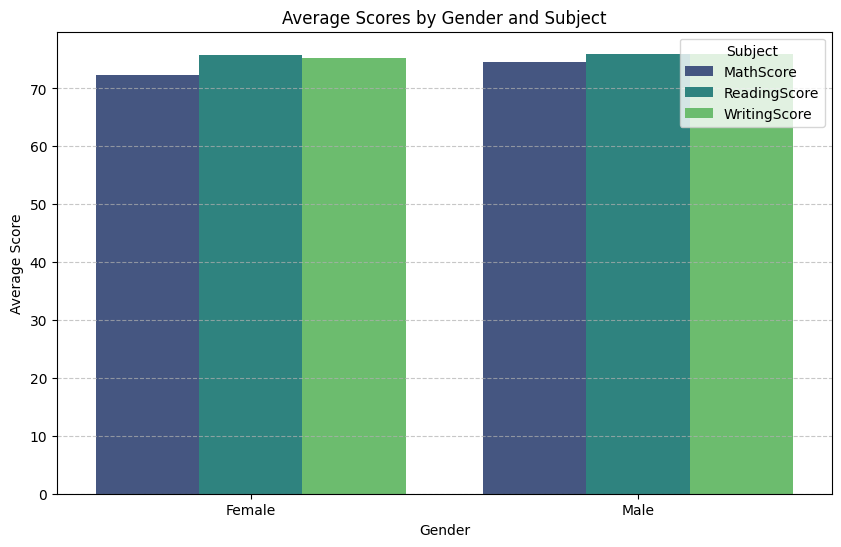

In [52]:
# i. Analyze average performance across gender using a grouped bar chart
gender_performance = student_df.groupby('Gender')[['MathScore', 'ReadingScore', 'WritingScore']].mean().reset_index()

gender_performance_melted = gender_performance.melt(id_vars='Gender', var_name='Subject', value_name='AverageScore')

plt.figure(figsize=(10, 6))
sns.barplot(x='Gender', y='AverageScore', hue='Subject', data=gender_performance_melted, palette='viridis')
plt.title('Average Scores by Gender and Subject')
plt.xlabel('Gender')
plt.ylabel('Average Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Subject')
plt.show()


#### ii. Examine the effect of parental education on student scores by creating box plots for Math, Reading, and Writing grouped by parental education levels.

/tmp/ipykernel_542/3626983430.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ParentalEducation', y='MathScore', data=student_df, palette='Set2')
/tmp/ipykernel_542/3626983430.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ParentalEducation', y='ReadingScore', data=student_df, palette='Set2')
/tmp/ipykernel_542/3626983430.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ParentalEducation', y='WritingScore', data=student_df, palette='Set2')


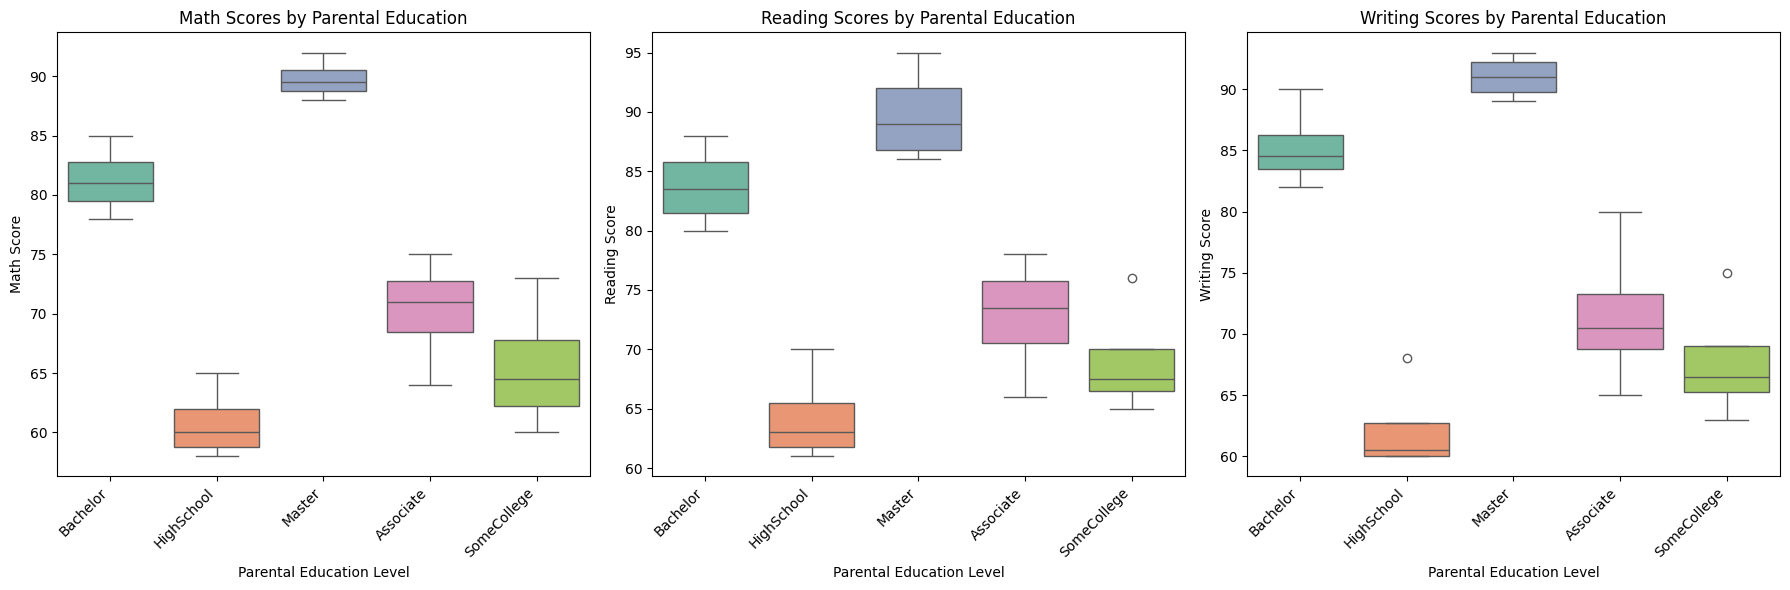

In [53]:
# ii. Examine the effect of parental education on student scores using box plots

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1) # Math Score
sns.boxplot(x='ParentalEducation', y='MathScore', data=student_df, palette='Set2')
plt.title('Math Scores by Parental Education')
plt.xlabel('Parental Education Level')
plt.ylabel('Math Score')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 3, 2) # Reading Score
sns.boxplot(x='ParentalEducation', y='ReadingScore', data=student_df, palette='Set2')
plt.title('Reading Scores by Parental Education')
plt.xlabel('Parental Education Level')
plt.ylabel('Reading Score')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 3, 3) # Writing Score
sns.boxplot(x='ParentalEducation', y='WritingScore', data=student_df, palette='Set2')
plt.title('Writing Scores by Parental Education')
plt.xlabel('Parental Education Level')
plt.ylabel('Writing Score')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()


#### iii. Investigate the impact of lunch type (standard vs. free/reduced) on academic performance using violin plots or box plots to display score distributions.

/tmp/ipykernel_542/1275804618.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Lunch', y='MathScore', data=student_df, palette='coolwarm')
/tmp/ipykernel_542/1275804618.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Lunch', y='ReadingScore', data=student_df, palette='coolwarm')
/tmp/ipykernel_542/1275804618.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Lunch', y='WritingScore', data=student_df, palette='coolwarm')


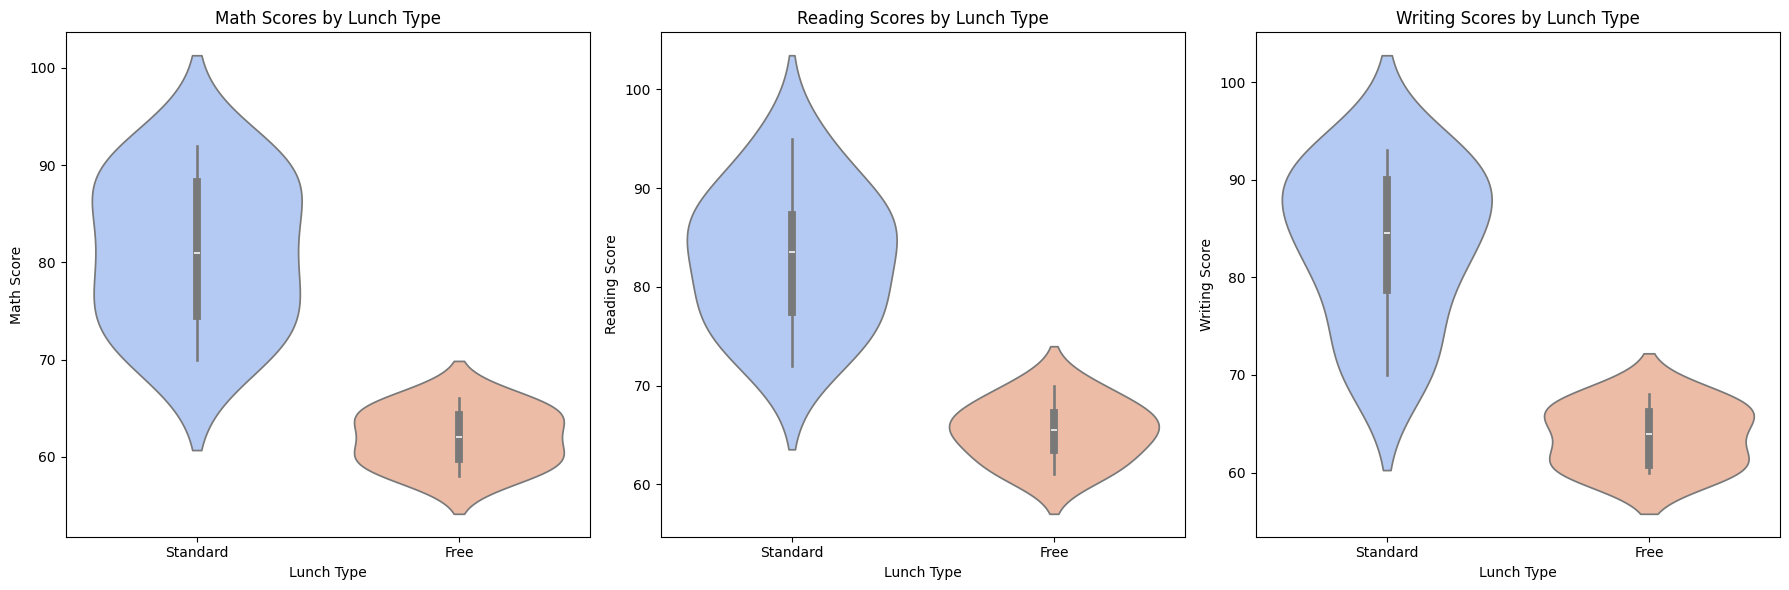

In [56]:
# iii. Investigate the impact of lunch type on academic performance using violin plots

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1) # Math Score
sns.violinplot(x='Lunch', y='MathScore', data=student_df, palette='coolwarm')
plt.title('Math Scores by Lunch Type')
plt.xlabel('Lunch Type')
plt.ylabel('Math Score')

plt.subplot(1, 3, 2) # Reading Score
sns.violinplot(x='Lunch', y='ReadingScore', data=student_df, palette='coolwarm')
plt.title('Reading Scores by Lunch Type')
plt.xlabel('Lunch Type')
plt.ylabel('Reading Score')

plt.subplot(1, 3, 3) # Writing Score
sns.violinplot(x='Lunch', y='WritingScore', data=student_df, palette='coolwarm')
plt.title('Writing Scores by Lunch Type')
plt.xlabel('Lunch Type')
plt.ylabel('Writing Score')

plt.tight_layout()
plt.show()


#### iv. Explore the correlation between Math, Reading, and Writing scores by generating a heatmap of the correlation matrix and a pair plot to understand score interdependence.

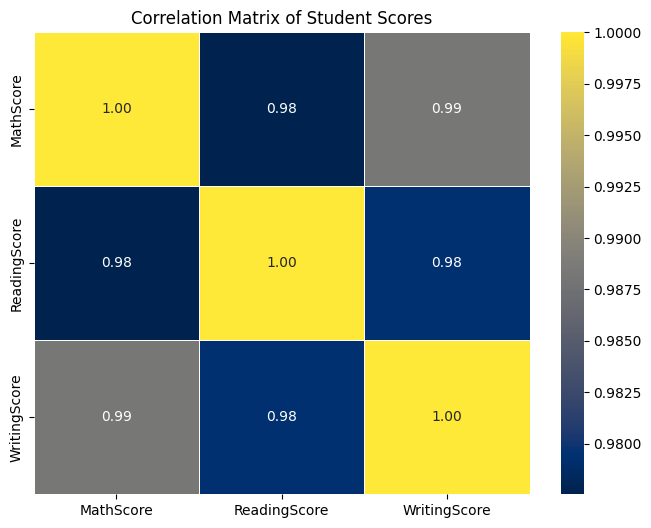

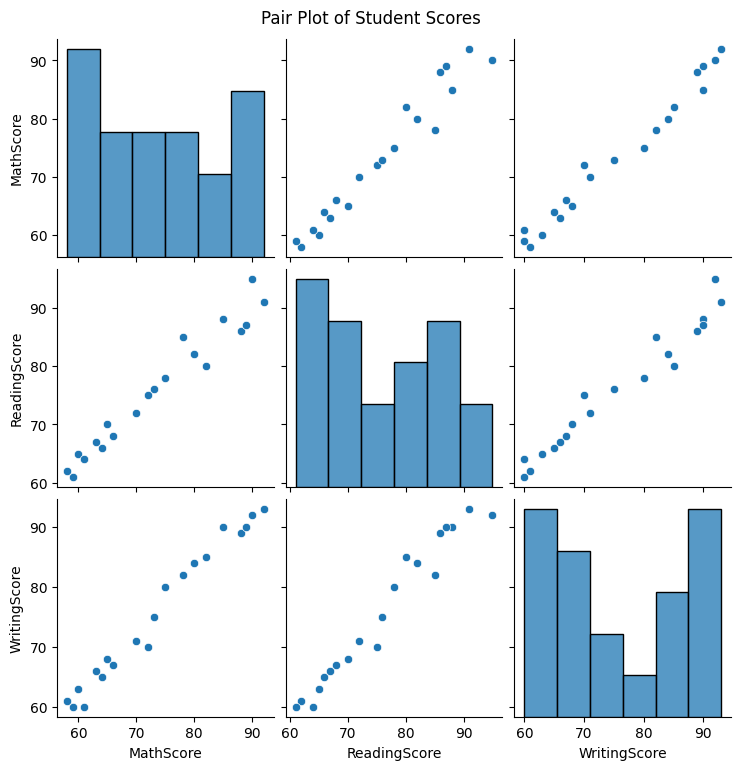

In [55]:
# iv. Explore the correlation between Math, Reading, and Writing scores

# Calculate the correlation matrix for the scores
score_correlation = student_df[['MathScore', 'ReadingScore', 'WritingScore']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(score_correlation, annot=True, cmap='cividis', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Student Scores')
plt.show()

# Generate a pair plot to visualize relationships between all score pairs
sns.pairplot(student_df[['MathScore', 'ReadingScore', 'WritingScore']])
plt.suptitle('Pair Plot of Student Scores', y=1.02) # Adjust title position
plt.show()


---

<div align="center">

### Declaration

_I hereby declare that the work submitted in this practical assignment is my own and has not been copied from any other source._

| | |
|---|---|
| **Student Name** | Shantanu Suryawanshi |
| **PRN** | 125M1H026 |
| **Date** | 26-08-2026 |


**Prof. Prakash Ukhalkar**  
Course Teacher - Advanced Data Science Lab [MCA33PE21]

![](https://img.shields.io/badge/MCA33PE21-Advanced%20Data%20Science%20Lab-blue?style=flat-square)
![](https://img.shields.io/badge/Practical%20Assignment-01-green?style=flat-square)

</div>